In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (12,6)

In [3]:
df = pd.read_csv(
    r"C:\Users\geeta\OneDrive\Desktop\coding\Python\Projects\Business KPI Dashboard\Data\raw_data.csv",
    encoding="latin1"
)

In [4]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [5]:
# Total Revenue
total_revenue = df['Sales'].sum()

print("Total Revenue: ${:,.2f}".format(total_revenue))

Total Revenue: $2,297,200.86


In [4]:
# Total Orders
total_orders = df['Order ID'].nunique()

print("Total Orders:", total_orders)

Total Orders: 5009


In [7]:
# Average Order Value (AOV)
aov = total_revenue / total_orders

print("Average Order Value: ${:,.2f}".format(aov))

Average Order Value: $458.61


In [8]:
df['Month-Year'] = (
    df['Order Date']
    .dt.to_period('M')
)

In [9]:
monthly_revenue = (
    df.groupby('Month-Year')['Sales']
    .sum()
    .reset_index()
)

monthly_revenue

,Month-Year,Sales
0,2014-01,14236.8950
1,2014-02,4519.8920
2,2014-03,55691.0090
3,2014-04,28295.3450
4,2014-05,23648.2870
5,2014-06,34595.1276
6,2014-07,33946.3930
7,2014-08,27909.4685
8,2014-09,81777.3508
9,2014-10,31453.3930


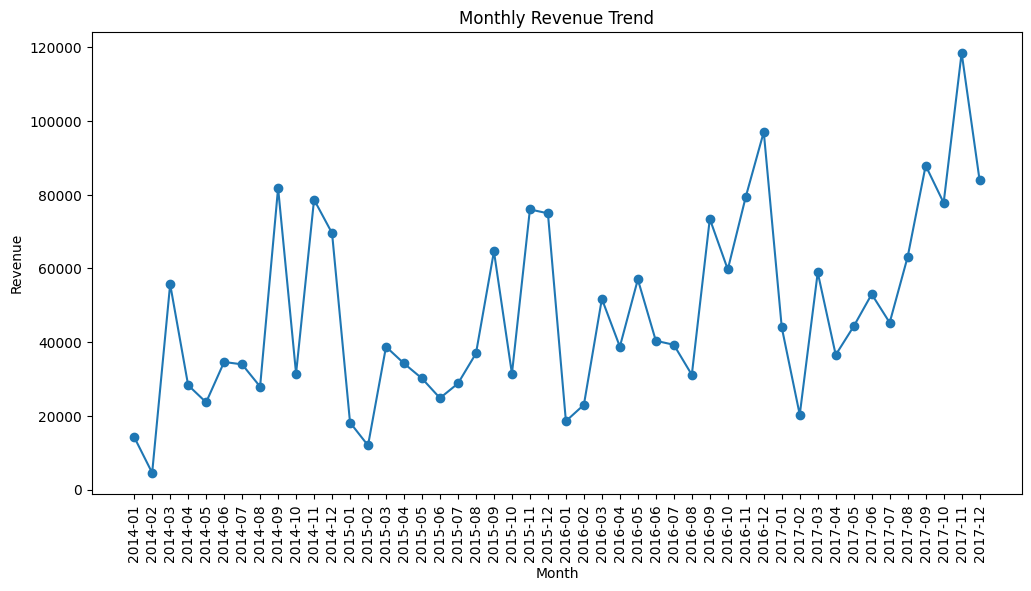

In [10]:
plt.plot(
    monthly_revenue['Month-Year'].astype(str),
    monthly_revenue['Sales'],
    marker='o'
)

plt.xticks(rotation=90)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.show()

In [ ]:
# Monthly Revenue Growth %
monthly_revenue['Growth %'] = (
    monthly_revenue['Sales']
    .pct_change()
) * 100

monthly_revenue.head()

,Month-Year,Sales,Growth %
0,2014-01,14236.895,NaN
1,2014-02,4519.892,-68.252263
2,2014-03,55691.009,1132.131409
3,2014-04,28295.345,-49.192257
4,2014-05,23648.287,-16.423401


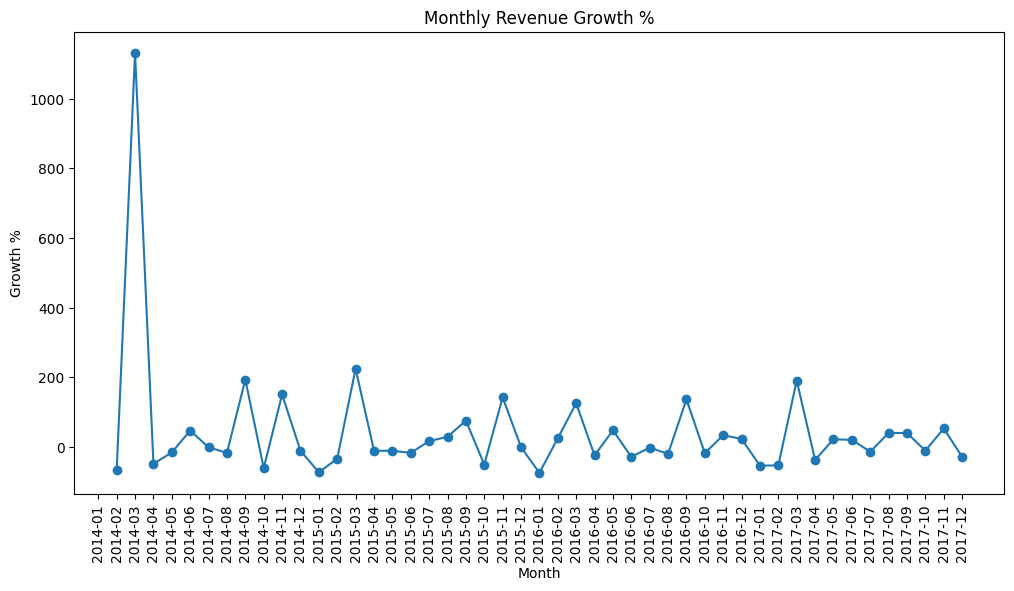

In [12]:
plt.plot(
    monthly_revenue['Month-Year'].astype(str),
    monthly_revenue['Growth %'],
    marker='o'
)

plt.xticks(rotation=90)

plt.title("Monthly Revenue Growth %")
plt.xlabel("Month")
plt.ylabel("Growth %")

plt.show()

In [13]:
revenue_region = (
    df.groupby('Region')['Sales']
    .sum()
    .sort_values(ascending=False)
)

revenue_region

Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64

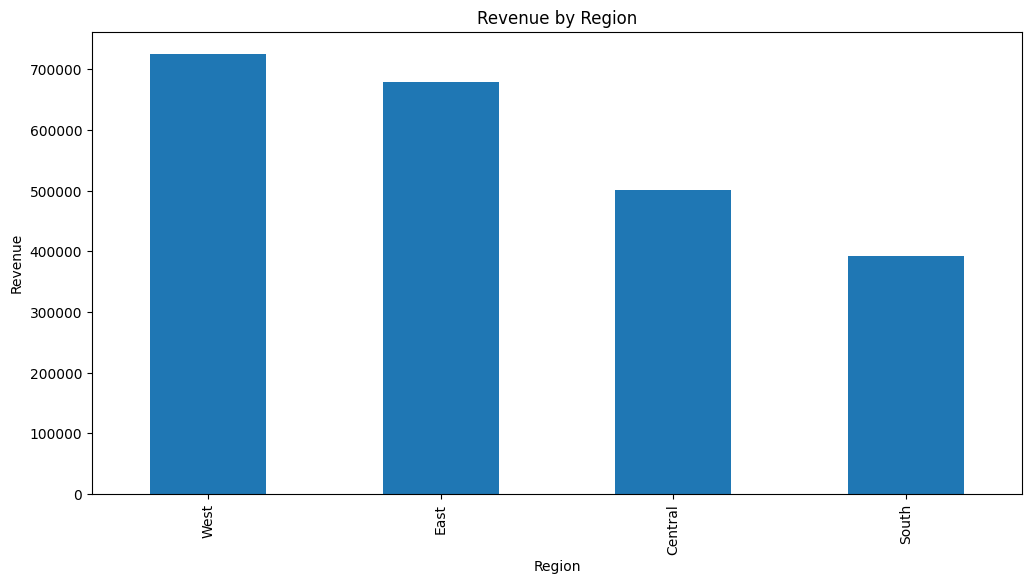

In [16]:
revenue_region.plot(
    kind='bar'
)

plt.title("Revenue by Region")
plt.ylabel("Revenue")

plt.show()

In [17]:
revenue_category = (
    df.groupby('Category')['Sales']
    .sum()
    .sort_values(ascending=False)
)

revenue_category

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64

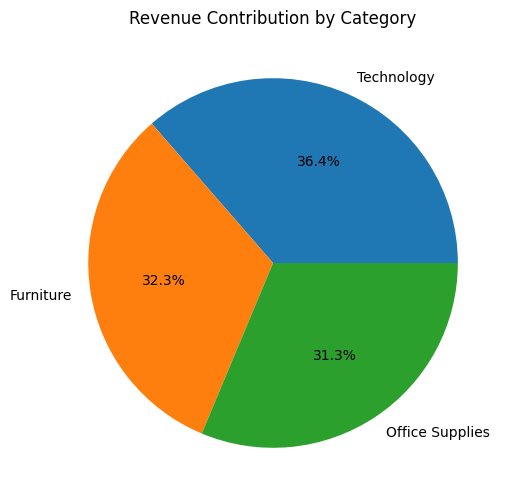

In [22]:
revenue_category.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Revenue Contribution by Category")
plt.ylabel("")

plt.show()

In [23]:
# Revenue by Customer Segment
segment_revenue = (
    df.groupby('Segment')['Sales']
    .sum()
    .sort_values(ascending=False)
)

segment_revenue

Segment
Consumer       1.161401e+06
Corporate      7.061464e+05
Home Office    4.296531e+05
Name: Sales, dtype: float64

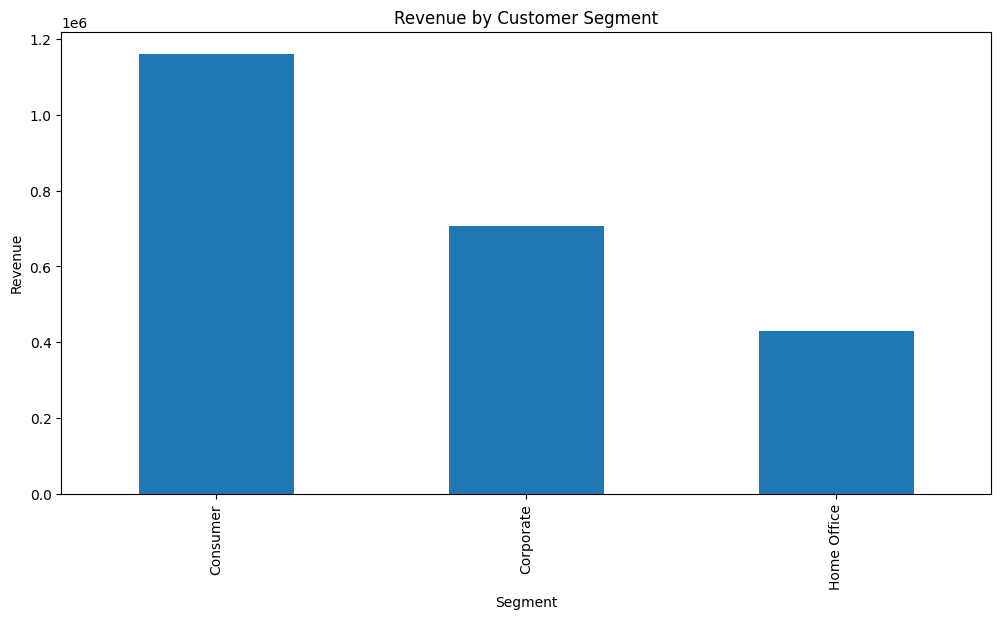

In [24]:
segment_revenue.plot(
    kind='bar'
)

plt.title("Revenue by Customer Segment")
plt.ylabel("Revenue")

plt.show()

In [25]:
# Top 10 Products by Revenue
top_products = (
    df.groupby('Sub-Category')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

Sub-Category
Phones         330007.0540
Chairs         328449.1030
Storage        223843.6080
Tables         206965.5320
Binders        203412.7330
Machines       189238.6310
Accessories    167380.3180
Copiers        149528.0300
Bookcases      114879.9963
Appliances     107532.1610
Name: Sales, dtype: float64

In [26]:
# Revenue Contribution %

category_contribution = (
    df.groupby('Category')['Sales']
    .sum() / total_revenue
) * 100

category_contribution

Category
Furniture          32.300171
Office Supplies    31.301008
Technology         36.398821
Name: Sales, dtype: float64

In [27]:
kpi_summary = pd.DataFrame({
    'KPI': [
        'Total Revenue',
        'Total Orders',
        'Average Order Value'
    ],
    
    'Value': [
        total_revenue,
        total_orders,
        aov
    ]
})

kpi_summary

,KPI,Value
0,Total Revenue,2.297201e+06
1,Total Orders,5.009000e+03
2,Average Order Value,4.586147e+02


# ---------------- Profit KPI Analysis----------------

In [28]:
# Total Profit

total_profit = df['Profit'].sum()

print("Total Profit: ${:,.2f}".format(total_profit))

Total Profit: $286,397.02


In [29]:
# Profit Margin %

profit_margin = (
    df['Profit'].sum() /
    df['Sales'].sum()
) * 100

print("Profit Margin: {:.2f}%".format(profit_margin))

Profit Margin: 12.47%


In [30]:
# Profit by Region Analysis
profit_region = (
    df.groupby('Region')['Profit']
    .sum()
    .sort_values(ascending=False)
)

profit_region

Region
West       108418.4489
East        91522.7800
South       46749.4303
Central     39706.3625
Name: Profit, dtype: float64

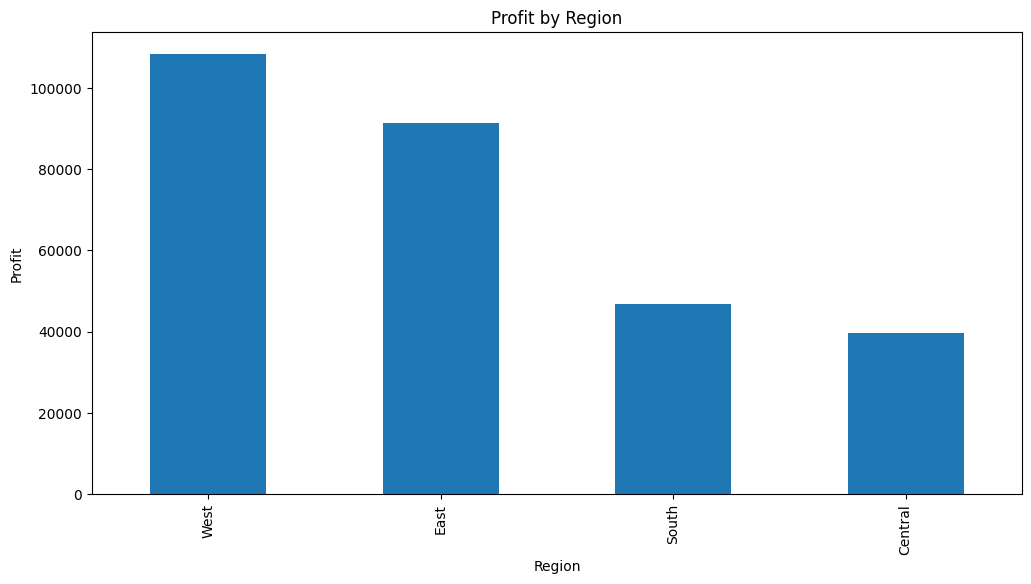

In [31]:
profit_region.plot(
    kind='bar'
)

plt.title("Profit by Region")
plt.ylabel("Profit")

plt.show()

In [33]:
# Profit by Category Analysis
profit_category = (
    df.groupby('Category')['Profit']
    .sum()
    .sort_values(ascending=False)
)

profit_category

Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64

In [35]:
# Profit by Sub-Category

subcategory_profit = (
    df.groupby('Sub-Category')['Profit']
    .sum()
    .sort_values(ascending=False)
)

subcategory_profit

Sub-Category
Copiers        55617.8249
Phones         44515.7306
Accessories    41936.6357
Paper          34053.5693
Binders        30221.7633
Chairs         26590.1663
Storage        21278.8264
Appliances     18138.0054
Furnishings    13059.1436
Envelopes       6964.1767
Art             6527.7870
Labels          5546.2540
Machines        3384.7569
Fasteners        949.5182
Supplies       -1189.0995
Bookcases      -3472.5560
Tables        -17725.4811
Name: Profit, dtype: float64

In [36]:
# Find Loss-Making Products
loss_products = (
    df.groupby('Sub-Category')['Profit']
    .sum()
    .sort_values()
    .head(10)
)

loss_products

Sub-Category
Tables        -17725.4811
Bookcases      -3472.5560
Supplies       -1189.0995
Fasteners        949.5182
Machines        3384.7569
Labels          5546.2540
Art             6527.7870
Envelopes       6964.1767
Furnishings    13059.1436
Appliances     18138.0054
Name: Profit, dtype: float64

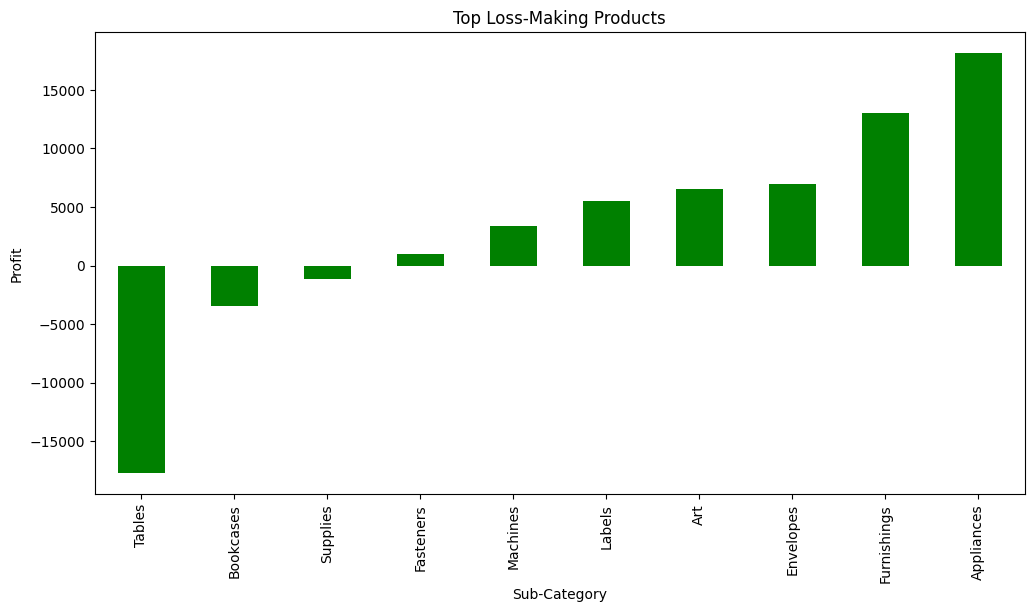

In [38]:
loss_products.plot(
    kind='bar',
    color='green'
)

plt.title("Top Loss-Making Products")
plt.ylabel("Profit")

plt.show()

In [39]:
# Discount Impact on Profit

# Correlation Analysis
df[['Discount', 'Profit']].corr()

,Discount,Profit
Discount,1.000000,-0.219487
Profit,-0.219487,1.000000


In [41]:
# Average Profit Per Order
total_orders = df['Order ID'].nunique()

avg_profit_order = total_profit / total_orders

print(
    "Average Profit Per Order: ${:.2f}"
    .format(avg_profit_order)
)

Average Profit Per Order: $57.18


In [44]:
monthly_profit = (
    df.groupby('Month-Year')['Profit']
    .sum()
    .reset_index()
)

monthly_profit

,Month-Year,Profit
0,2014-01,2450.1907
1,2014-02,862.3084
2,2014-03,498.7299
3,2014-04,3488.8352
4,2014-05,2738.7096
5,2014-06,4976.5244
6,2014-07,-841.4826
7,2014-08,5318.1050
8,2014-09,8328.0994
9,2014-10,3448.2573


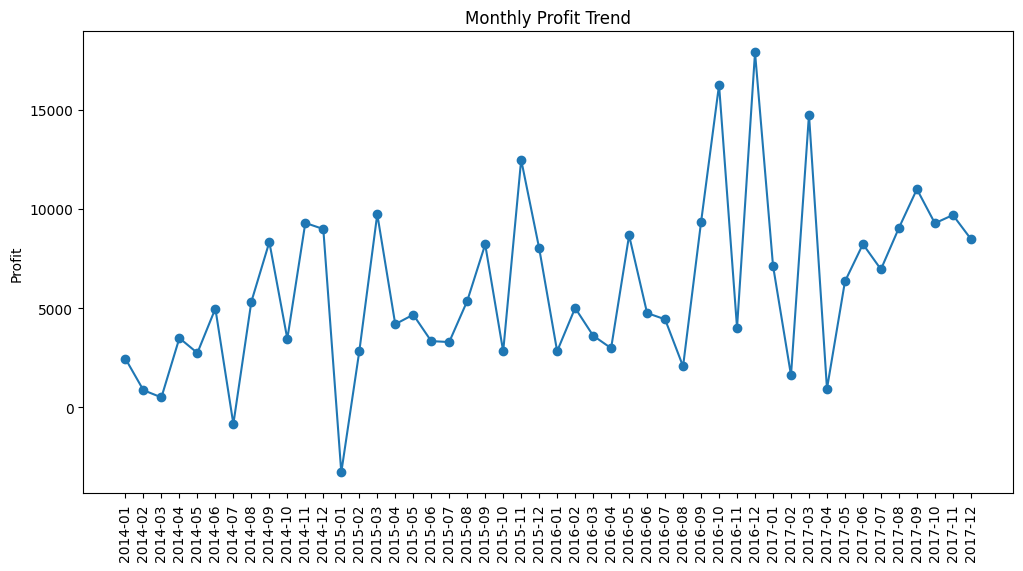

In [45]:
plt.plot(
    monthly_profit['Month-Year'].astype(str),
    monthly_profit['Profit'],
    marker='o'
)

plt.xticks(rotation=90)

plt.title("Monthly Profit Trend")
plt.ylabel("Profit")

plt.show()

In [46]:
profit_heatmap = df.pivot_table(
    values='Profit',
    index='Region',
    columns='Category',
    aggfunc='sum'
)

profit_heatmap

Category,Furniture,Office Supplies,Technology
Region,,,
Central,-2871.0494,8879.9799,33697.4320
East,3046.1658,41014.5791,47462.0351
South,6771.2061,19986.3928,19991.8314
West,11504.9503,52609.8490,44303.6496


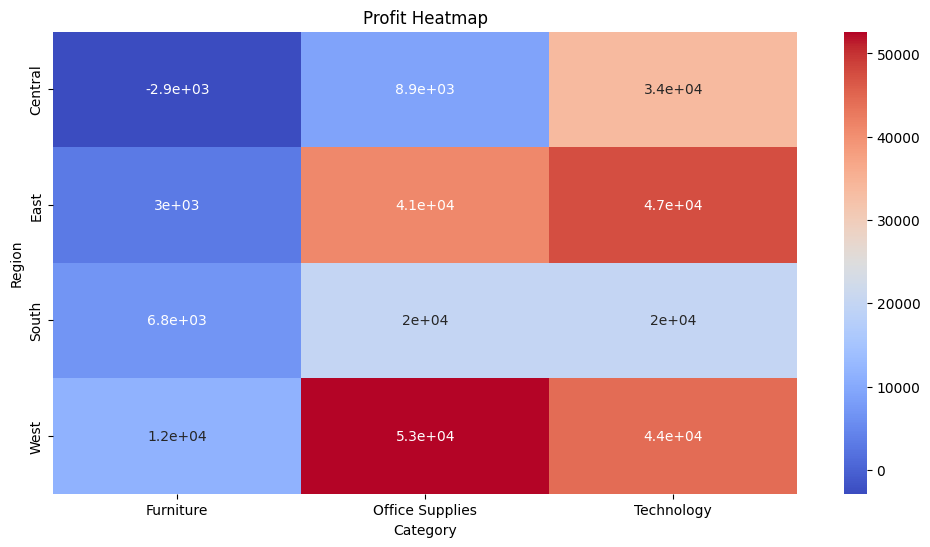

In [47]:
sns.heatmap(
    profit_heatmap,
    annot=True,
    cmap='coolwarm'
)

plt.title("Profit Heatmap")

plt.show()

In [48]:
profit_summary = pd.DataFrame({
    'KPI': [
        'Total Profit',
        'Profit Margin %',
        'Average Profit Per Order'
    ],

    'Value': [
        round(total_profit,2),
        round(profit_margin,2),
        round(avg_profit_order,2)
    ]
})

profit_summary

,KPI,Value
0,Total Profit,286397.02
1,Profit Margin %,12.47
2,Average Profit Per Order,57.18


<!-- Customer KPI Analysis -->

In [ ]:
# KPI 1 — Top Customers
#  Top Customers by Revenue
top_customers = (
    df.groupby('Customer Name')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_customers

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64

In [ ]:
# KPI 2 — Customer Lifetime Value (CLV)
# Calculate Unique Customers
total_customers = df['Customer ID'].nunique()

print("Total Customers:", total_customers)

Total Customers: 793


In [54]:
# Calculate CLV
customer_lifetime_value = (
    df['Sales'].sum() /
    total_customers
)

print(
    "Customer Lifetime Value: ${:.2f}"
    .format(customer_lifetime_value)
)

Customer Lifetime Value: $2896.85


In [ ]:
# KPI 3 — Repeat Customers
repeat_customers = (
    df.groupby('Customer Name')['Order ID']
    .nunique()
    .sort_values(ascending=False)
)

repeat_customers.head(10)

Customer Name
Emily Phan             17
Sally Hughsby          13
Noel Staavos           13
Patrick Gardner        13
Zuschuss Carroll       13
Joel Eaton             13
Erin Ashbrook          13
Chloris Kastensmidt    13
Suzanne McNair         12
Rick Bensley           12
Name: Order ID, dtype: int64

In [56]:
# Count Customers with Multiple Orders
repeat_count = (
    repeat_customers[repeat_customers > 1]
    .count()
)

print("Repeat Customers:", repeat_count)

Repeat Customers: 781


In [57]:
# KPI 4 — Segment Analysis
# Revenue by Segment
segment_sales = (
    df.groupby('Segment')['Sales']
    .sum()
    .sort_values(ascending=False)
)

segment_sales

Segment
Consumer       1.161401e+06
Corporate      7.061464e+05
Home Office    4.296531e+05
Name: Sales, dtype: float64

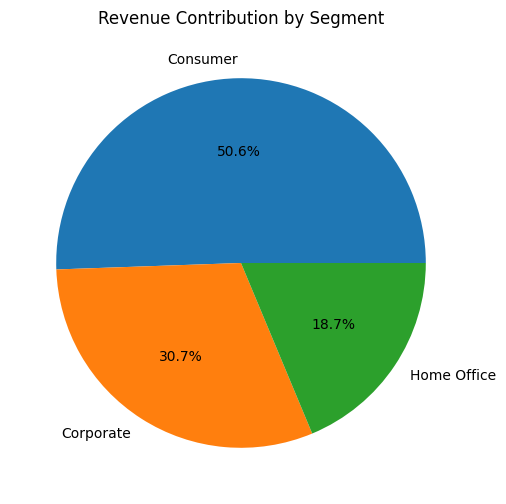

In [62]:
segment_sales.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Revenue Contribution by Segment")
plt.ylabel("")

plt.show()

In [63]:
# KPI 5 — Average Customer Spend

avg_customer_spend = (
    df['Sales'].sum() /
    total_customers
)

print(
    "Average Customer Spend: ${:.2f}"
    .format(avg_customer_spend)
)

Average Customer Spend: $2896.85


In [64]:
# KPI 6 — Customer Profitability

# Profit by Customer
customer_profit = (
    df.groupby('Customer Name')['Profit']
    .sum()
    .sort_values(ascending=False)
)

customer_profit.head(10)

Customer Name
Tamara Chand            8981.3239
Raymond Buch            6976.0959
Sanjit Chand            5757.4119
Hunter Lopez            5622.4292
Adrian Barton           5444.8055
Tom Ashbrook            4703.7883
Christopher Martinez    3899.8904
Keith Dawkins           3038.6254
Andy Reiter             2884.6208
Daniel Raglin           2869.0760
Name: Profit, dtype: float64

In [ ]:
# KPI 7 — RFM Analysis
reference_date = df['Order Date'].max()

In [66]:
rfm = df.groupby('Customer ID').agg({
    'Order Date': lambda x:
        (reference_date - x.max()).days,

    'Order ID': 'nunique',

    'Sales': 'sum'
})

In [67]:
rfm.columns = [
    'Recency',
    'Frequency',
    'Monetary'
]

rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
AA-10315,184,5,5563.560
AA-10375,19,9,1056.390
AA-10480,259,4,1790.512
AA-10645,55,6,5086.935
AB-10015,415,3,886.156


In [68]:
# RFM Scores
rfm['R_Score'] = pd.qcut(
    rfm['Recency'],
    4,
    labels=[4,3,2,1]
)

rfm['F_Score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    4,
    labels=[1,2,3,4]
)

rfm['M_Score'] = pd.qcut(
    rfm['Monetary'],
    4,
    labels=[1,2,3,4]
)

In [69]:
# Create Final RFM Score
rfm['RFM Score'] = (
    rfm['R_Score'].astype(str) +
    rfm['F_Score'].astype(str) +
    rfm['M_Score'].astype(str)
)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM Score
Customer ID,,,,,,,
AA-10315,184,5,5563.560,1,1,4,114
AA-10375,19,9,1056.390,4,4,1,441
AA-10480,259,4,1790.512,1,1,2,112
AA-10645,55,6,5086.935,3,2,4,324
AB-10015,415,3,886.156,1,1,1,111


In [70]:
# KPI 8 — High-Value Customers
high_value_customers = rfm.sort_values(
    by='Monetary',
    ascending=False
).head(10)

high_value_customers

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM Score
Customer ID,,,,,,,
SM-20320,79,5,25043.050,2,2,4,224
TC-20980,399,5,19052.218,1,2,4,124
RB-19360,96,6,15117.339,2,3,4,234
TA-21385,69,4,14595.620,3,1,4,314
AB-10105,41,10,14473.571,3,4,4,344
KL-16645,47,12,14175.229,3,4,4,344
SC-20095,349,9,14142.334,1,4,4,144
HL-15040,43,6,12873.298,3,2,4,324
SE-20110,9,11,12209.438,4,4,4,444


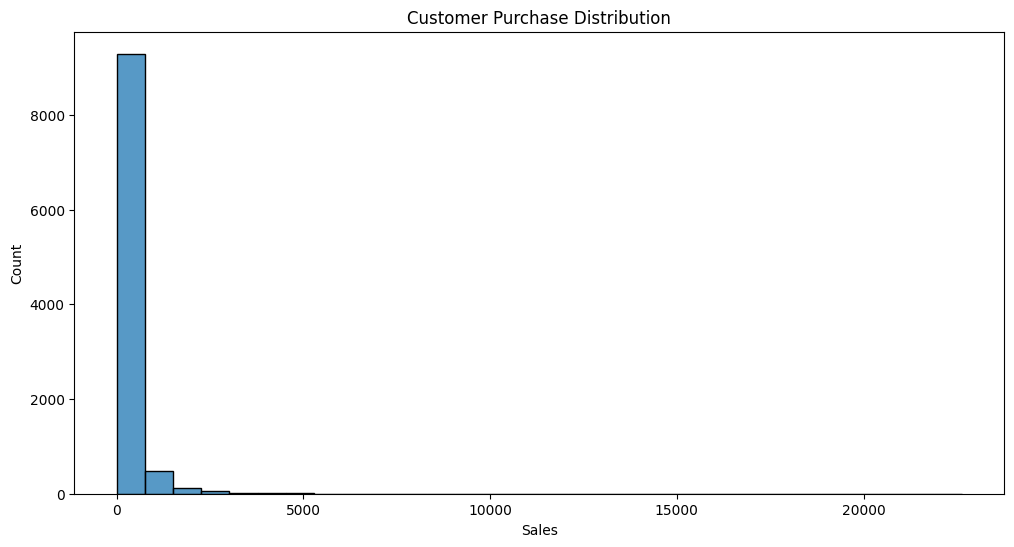

In [71]:
# KPI 9 — Customer Distribution
sns.histplot(
    df['Sales'],
    bins=30
)

plt.title("Customer Purchase Distribution")

plt.show()

In [72]:
customer_summary = pd.DataFrame({
    'KPI': [
        'Total Customers',
        'Repeat Customers',
        'Customer Lifetime Value',
        'Average Customer Spend'
    ],

    'Value': [
        total_customers,
        repeat_count,
        round(customer_lifetime_value,2),
        round(avg_customer_spend,2)
    ]
})

customer_summary

,KPI,Value
0,Total Customers,793.00
1,Repeat Customers,781.00
2,Customer Lifetime Value,2896.85
3,Average Customer Spend,2896.85


<!-- Product KPI Analysis -->

In [5]:
# KPI 1 — Best-Selling Products
best_selling_products = (
    df.groupby('Sub-Category')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

best_selling_products

Sub-Category
Phones         330007.0540
Chairs         328449.1030
Storage        223843.6080
Tables         206965.5320
Binders        203412.7330
Machines       189238.6310
Accessories    167380.3180
Copiers        149528.0300
Bookcases      114879.9963
Appliances     107532.1610
Name: Sales, dtype: float64

In [6]:
# KPI 2 — Low-Performing Products
low_performing_products = (
    df.groupby('Sub-Category')['Sales']
    .sum()
    .sort_values()
    .head(10)
)

low_performing_products

Sub-Category
Fasteners        3024.2800
Labels          12486.3120
Envelopes       16476.4020
Art             27118.7920
Supplies        46673.5380
Paper           78479.2060
Furnishings     91705.1640
Appliances     107532.1610
Bookcases      114879.9963
Copiers        149528.0300
Name: Sales, dtype: float64

In [7]:
# Category Sales
category_sales = (
    df.groupby('Category')['Sales']
    .sum()
    .sort_values(ascending=False)
)

category_sales

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64

In [8]:
category_contribution = (
    category_sales /
    df['Sales'].sum()
) * 100

category_contribution

Category
Technology         36.398821
Furniture          32.300171
Office Supplies    31.301008
Name: Sales, dtype: float64

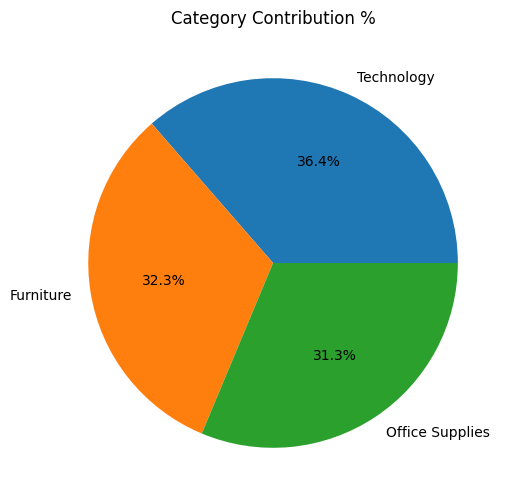

In [10]:
category_contribution.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Category Contribution %")
plt.ylabel("")

plt.show()

In [ ]:
# KPI 4 — Product Profitability
product_profitability = (
    df.groupby('Sub-Category')['Profit']
    .sum()
    .sort_values(ascending=False)
)

product_profitability
# High sales does NOT always mean high profit.

Sub-Category
Copiers        55617.8249
Phones         44515.7306
Accessories    41936.6357
Paper          34053.5693
Binders        30221.7633
Chairs         26590.1663
Storage        21278.8264
Appliances     18138.0054
Furnishings    13059.1436
Envelopes       6964.1767
Art             6527.7870
Labels          5546.2540
Machines        3384.7569
Fasteners        949.5182
Supplies       -1189.0995
Bookcases      -3472.5560
Tables        -17725.4811
Name: Profit, dtype: float64

In [12]:
# KPI 5 — Loss-Making Products
# Bottom Products by Profit
loss_products = (
    df.groupby('Sub-Category')['Profit']
    .sum()
    .sort_values()
    .head(10)
)

loss_products

Sub-Category
Tables        -17725.4811
Bookcases      -3472.5560
Supplies       -1189.0995
Fasteners        949.5182
Machines        3384.7569
Labels          5546.2540
Art             6527.7870
Envelopes       6964.1767
Furnishings    13059.1436
Appliances     18138.0054
Name: Profit, dtype: float64

In [13]:
# KPI 6 — Inventory Insights

# Products by Quantity Sold
quantity_analysis = (
    df.groupby('Sub-Category')['Quantity']
    .sum()
    .sort_values(ascending=False)
)

quantity_analysis

Sub-Category
Binders        5974
Paper          5178
Furnishings    3563
Phones         3289
Storage        3158
Art            3000
Accessories    2976
Chairs         2356
Appliances     1729
Labels         1400
Tables         1241
Fasteners       914
Envelopes       906
Bookcases       868
Supplies        647
Machines        440
Copiers         234
Name: Quantity, dtype: int64

In [14]:
# KPI 7 — Average Selling Price

df['Average Selling Price'] = (
    df['Sales'] /
    df['Quantity']
)

df[['Sub-Category',
    'Average Selling Price']].head()

,Sub-Category,Average Selling Price
0,Bookcases,130.9800
1,Chairs,243.9800
2,Labels,7.3100
3,Tables,191.5155
4,Storage,11.1840


In [16]:
# Create Pareto Table
pareto = (
    df.groupby('Sub-Category')['Sales']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

pareto.columns = [
    'Sub-Category',
    'Sales'
]

pareto['Cumulative %'] = (
    pareto['Sales'].cumsum() /
    pareto['Sales'].sum()
) * 100

pareto

,Sub-Category,Sales,Cumulative %
0,Phones,330007.0540,14.365616
1,Chairs,328449.1030,28.663412
2,Storage,223843.6080,38.407602
3,Tables,206965.5320,47.417068
4,Binders,203412.7330,56.271876
5,Machines,189238.6310,64.509669
6,Accessories,167380.3180,71.795941
7,Copiers,149528.0300,78.305082
8,Bookcases,114879.9963,83.305950
9,Appliances,107532.1610,87.986958


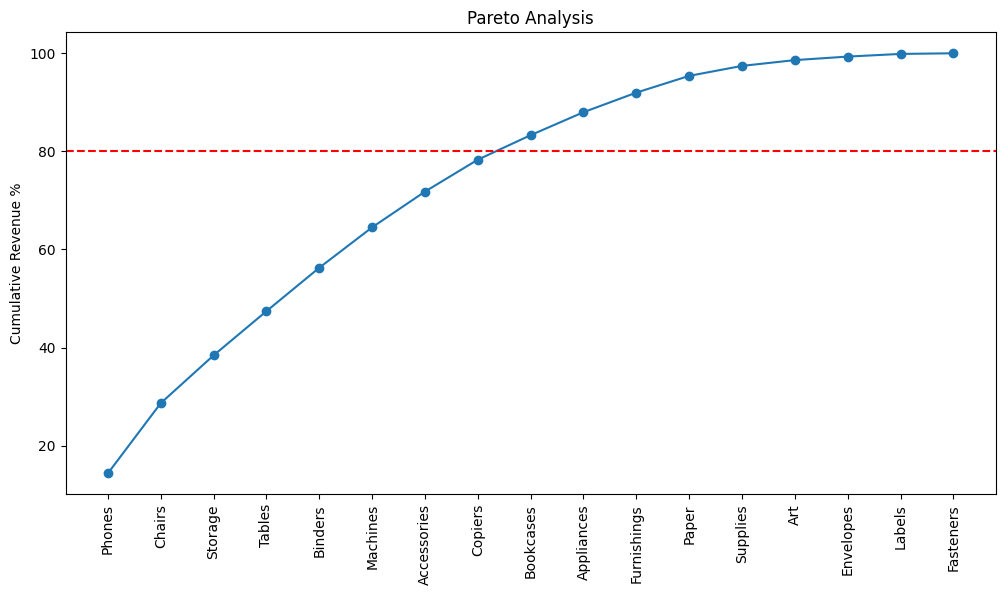

In [17]:
plt.plot(
    pareto['Sub-Category'],
    pareto['Cumulative %'],
    marker='o'
)

plt.xticks(rotation=90)

plt.axhline(
    y=80,
    color='red',
    linestyle='--'
)

plt.title("Pareto Analysis")
plt.ylabel("Cumulative Revenue %")

plt.show()

In [18]:
# KPI 9 — Top & Bottom Products Comparison

# Top Products
top_products = (
    df.groupby('Sub-Category')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

top_products

Sub-Category
Phones     330007.054
Chairs     328449.103
Storage    223843.608
Tables     206965.532
Binders    203412.733
Name: Sales, dtype: float64

In [19]:
# Bottom Products
bottom_products = (
    df.groupby('Sub-Category')['Sales']
    .sum()
    .sort_values()
    .head(5)
)

bottom_products

Sub-Category
Fasteners     3024.280
Labels       12486.312
Envelopes    16476.402
Art          27118.792
Supplies     46673.538
Name: Sales, dtype: float64

In [20]:
# KPI 10 — Discount vs Product Profitability

# Product-Level Discount Analysis
discount_profit = (
    df.groupby('Sub-Category')[
        ['Discount', 'Profit']
    ]
    .mean()
)

discount_profit

,Discount,Profit
Sub-Category,,
Accessories,0.078452,54.111788
Appliances,0.166524,38.922758
Art,0.074874,8.200737
Binders,0.372292,19.843574
Bookcases,0.211140,-15.230509
Chairs,0.170178,43.095894
Copiers,0.161765,817.909190
Envelopes,0.080315,27.418019
Fasteners,0.082028,4.375660


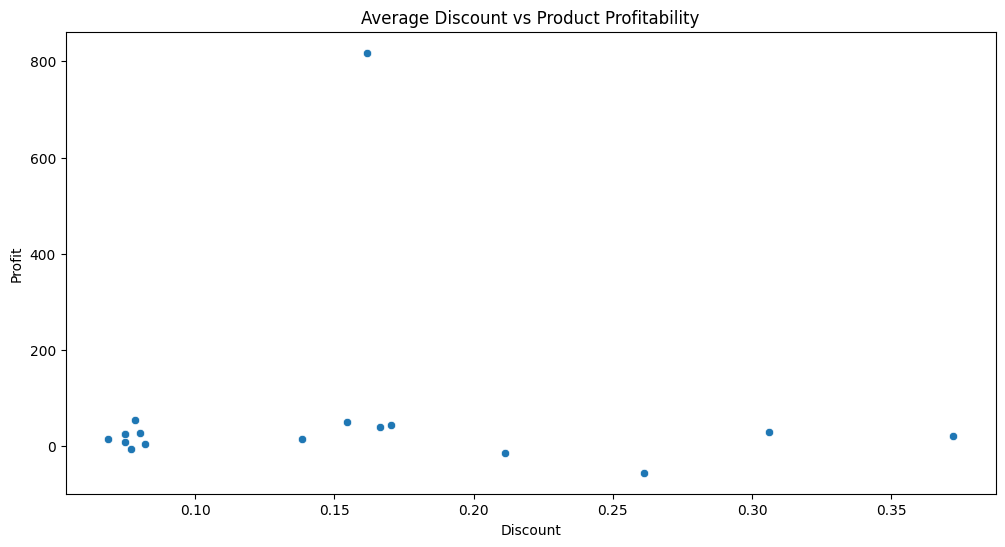

In [21]:
sns.scatterplot(
    data=discount_profit,
    x='Discount',
    y='Profit'
)

plt.title(
    "Average Discount vs Product Profitability"
)

plt.show()

In [22]:
product_summary = pd.DataFrame({
    'KPI': [
        'Top Product Category',
        'Most Profitable Product',
        'Lowest Performing Product'
    ],

    'Value': [
        category_sales.idxmax(),
        product_profitability.idxmax(),
        low_performing_products.idxmin()
    ]
})

product_summary

,KPI,Value
0,Top Product Category,Technology
1,Most Profitable Product,Copiers
2,Lowest Performing Product,Fasteners
